In [1]:
import math
import qewton

In [2]:
X = qewton.Variable("x", dim=2)
U = qewton.Variable("u", dim=1)

In [3]:
square = qewton.Square(X, [0.0, 0.0], 1.0, 1.0)

point_sampler = qewton.RandomUniformSampler(square, 10000)
points_sampler_boundary = qewton.RandomUniformSampler(square.boundary, 5000)

In [4]:
model = qewton.algorithms.FCN(
    in_neurons=X,
    hidden_neurons=25,
    out_neurons=U,
    n_hidden_layers=4,
    activation=qewton.building_blocks.Tanh,
)

In [ ]:
def residual_fun(u: U, x: X):  # type: ignore
    return u.laplacian(x) + 4*math.pi**2*u

pde_graph = qewton.PINNPipeline(point_sampler, [model], residual_fun=residual_fun, residual_name="PINNConstraint")

In [6]:
def boundary_residual_fun(u: U, x: X):  # type: ignore
    cos_1 = qewton.building_blocks.Cos()(2*math.pi*x[:, :1])
    cos_2 = qewton.building_blocks.Cos()(2*math.pi*x[:, 1:])
    return u - (cos_1 + cos_2)

boundary_constraint = qewton.constraints.PINNConstraint(
    boundary_residual_fun, name="BoundaryConstraint", weight=1000.0
)
boundary_graph = qewton.PINNPipeline(points_sampler_boundary, [model], boundary_constraint)

In [ ]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=5000,
)

lbfgs_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.LBFGS(),
    lr=0.1,
    max_iterations=100,
    optimizer_args={"max_eval": 10},
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase, lbfgs_phase],
    graphs=[boundary_graph, pde_graph],
    training_objectives=[boundary_constraint, constraint],
    device="cuda:0",
)

trainer.run()

/home/tomfre/miniconda3/envs/qewton/lib/python3.10/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
Optimization Phase 1:   0%|          | 0/5000 [00:00<?, ?it/s]

sampling took 0.0005702972412109375
sampling took 0.0006830692291259766
sampling took 0.0005190372467041016
sampling took 0.00037479400634765625


Optimization Phase 1:   0%|          | 23/5000 [00:00<01:54, 43.41it/s, loss=1.15e+3]

sampling took 0.0006062984466552734
sampling took 0.0004341602325439453
sampling took 0.0003509521484375
sampling took 0.0003719329833984375
sampling took 0.0003490447998046875
sampling took 0.0003883838653564453
sampling took 0.0003917217254638672
sampling took 0.00038623809814453125
sampling took 0.00037860870361328125
sampling took 0.00037670135498046875
sampling took 0.00035858154296875
sampling took 0.0003619194030761719
sampling took 0.0003905296325683594
sampling took 0.00038242340087890625
sampling took 0.0003566741943359375
sampling took 0.00039076805114746094
sampling took 0.00040531158447265625
sampling took 0.0003714561462402344
sampling took 0.00038361549377441406
sampling took 0.00038242340087890625
sampling took 0.000331878662109375
sampling took 0.00037360191345214844
sampling took 0.0003509521484375
sampling took 0.0003764629364013672
sampling took 0.0003905296325683594
sampling took 0.0003764629364013672
sampling took 0.0003025531768798828
sampling took 0.000377416610

Optimization Phase 1:   1%|          | 46/5000 [00:00<01:01, 81.19it/s, loss=1.13e+3]

...

Optimization Phase 1:  12%|█▏        | 595/5000 [00:07<01:01, 71.39it/s, loss=107]

sampling took 0.0013203620910644531
sampling took 0.00080108642578125
sampling took 0.0009319782257080078
sampling took 0.0007281303405761719
sampling took 0.0009253025054931641
sampling took 0.0007741451263427734
sampling took 0.0009846687316894531
sampling took 0.0007293224334716797
sampling took 0.000946044921875
sampling took 0.0007920265197753906
sampling took 0.0009412765502929688
sampling took 0.0009088516235351562
sampling took 0.0009622573852539062
sampling took 0.0008461475372314453
sampling took 0.0009419918060302734
sampling took 0.0009293556213378906
sampling took 0.0009372234344482422
sampling took 0.0008256435394287109
sampling took 0.0009615421295166016
sampling took 0.0008199214935302734
sampling took 0.0009167194366455078
sampling took 0.0009264945983886719
sampling took 0.0009698867797851562
sampling took 0.0009114742279052734
sampling took 0.0009331703186035156
sampling took 0.0009703636169433594
sampling took 0.0009417533874511719
sampling took 0.000886678695678710

Optimization Phase 1:  12%|█▏        | 609/5000 [00:08<01:04, 68.33it/s, loss=95.6]

sampling took 0.0008165836334228516
sampling took 0.0009658336639404297
sampling took 0.000850677490234375
sampling took 0.0009334087371826172
sampling took 0.0009057521820068359
sampling took 0.0009424686431884766
sampling took 0.0008847713470458984
sampling took 0.0009307861328125
sampling took 0.001127481460571289
sampling took 0.0010409355163574219
sampling took 0.0007891654968261719
sampling took 0.0009686946868896484
sampling took 0.0008721351623535156
sampling took 0.0009405612945556641
sampling took 0.0007953643798828125
sampling took 0.0009603500366210938
sampling took 0.0009522438049316406
sampling took 0.0009300708770751953
sampling took 0.0009410381317138672
sampling took 0.0009448528289794922
sampling took 0.0008146762847900391
sampling took 0.0009515285491943359
sampling took 0.0008614063262939453
sampling took 0.0009367465972900391
sampling took 0.0007658004760742188
sampling took 0.0009179115295410156
sampling took 0.0010135173797607422
sampling took 0.00095129013061523

Optimization Phase 1:  12%|█▏        | 611/5000 [00:08<01:04, 68.33it/s, loss=96.8]

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

model.to("cpu")

mesh_square = square.create_mesh(0.05)
coords = mesh_square.mesh.vertices
model_out = model(torch.tensor(coords)).detach().numpy()
expected_out = np.cos(2*math.pi*coords[:, :1]) + np.cos(2*math.pi*coords[:, 1:])
error = np.abs(model_out - expected_out)


/home/tomfre/Desktop/qewton-backend/src/qewton/geometries/discrete/mesh.py:116: RuntimeWarning: invalid value encountered in divide
  self.boundary_normals_at_vertex /= np.linalg.norm(


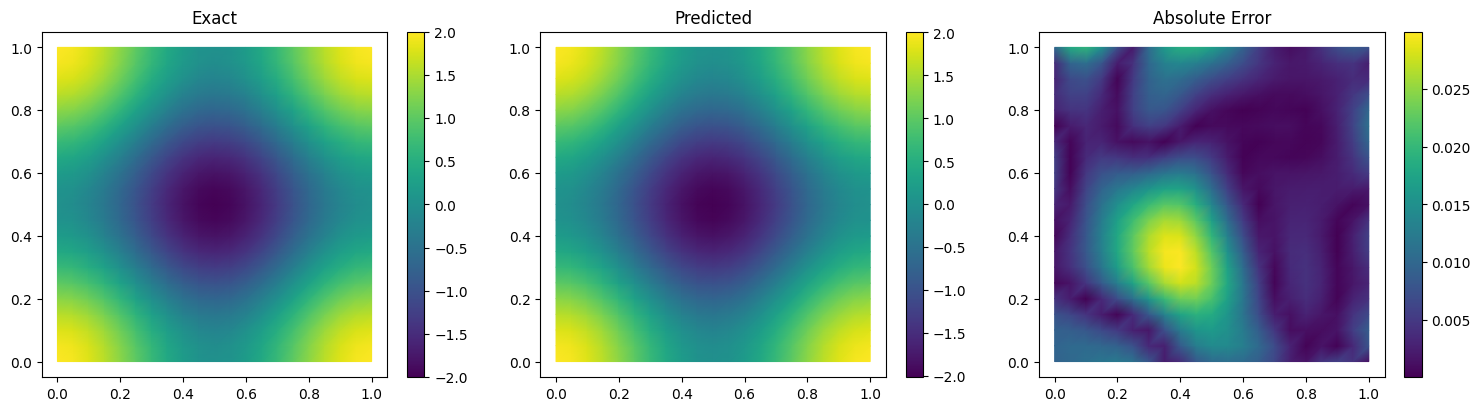

In [ ]:
expected_out = expected_out.ravel()
model_out = model_out.ravel()
error = error.ravel()

triang = mtri.Triangulation(
    coords[:, 0],
    coords[:, 1],
    triangles=mesh_square.mesh.cells,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# Exact solution
im0 = axes[0].tripcolor(
    triang,
    expected_out,
    shading="gouraud",
)
axes[0].set_title("Exact")
fig.colorbar(im0, ax=axes[0])

# PINN solution
im1 = axes[1].tripcolor(
    triang,
    model_out,
    shading="gouraud",
)
axes[1].set_title("Predicted")
fig.colorbar(im1, ax=axes[1])

# Error
im2 = axes[2].tripcolor(
    triang,
    error,
    shading="gouraud",
)
axes[2].set_title("Absolute Error")
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_aspect("equal")

plt.show()